In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import KernelDensity
import requests
import pandas as pd

[Descrizione del dataset sui Gamma Ray Bursts (GRBs)](https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html)

In [2]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str', unpack='True')

# Read headers
with open("Summary_table.txt", 'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

<ipython-input-2-1946fe33ee37>:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str', unpack='True')


In [3]:
table = pd.DataFrame(data.T, columns=names)

In [4]:
table

,GRB_name,GRB_name_Fermi,T0,ra,decl,pos_error,T90,T90_error,T90_start,fluence,fluence_error,redshift,'T100',GBM_located,mjd_(T0)
0,GRB250506A,GRB250506100,2:23:22,219.2827,28.8784,-999,48.1290,1.3050,2:23:23.372,1.7999e-05,5.1172e-08,-999,49.5010,False,60801.09956019
1,GRB250505A,GRB250505339,8:08:39,104.5800,-10.3300,3.299939,13.5680,1.1450,8:08:39.284,2.9059e-06,1.8857e-08,-999,13.8520,True,60800.33934028
2,GRB250504B*,GRB250504836,20:03:35.584,105.5900,85.1100,5.266584,230.9170,0.9230,20:03:36.608,1.3665e-05,3.7234e-08,-999,231.9410,True,60799.83582852
3,GRB250504A,GRB250504976,23:25:54,269.6181,-40.3668,0.000518,48.8970,1.0560,23:25:55.039,7.0208e-06,4.2396e-08,-999,49.9360,False,60799.97631944
4,GRB250502B,GRB250502426,10:13:53,312.2600,14.5300,3.036284,18.1730,0.5710,10:13:53.171,3.4854e-06,1.7362e-08,-999,18.3440,True,60797.42630787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8723,GRB910425B*,None,5:33:13.716,335.9500,25.7667,4.790000,430.0160,1.0940,5:33:13.716,1.3510e-06,6.3429e-08,-999,430.0160,False,48371.23140875
8724,GRB910425A*,None,0:37:45.700,91.3000,-22.7667,1.020000,90.1760,0.2860,0:37:49.924,1.3277e-05,6.8674e-08,-999,94.4000,False,48371.02622338
8725,GRB910424A*,None,19:43:25.064,201.3000,-45.4167,13.780000,3.1360,0.5900,19:43:25.064,2.4858e-08,1.0496e-08,-999,3.1360,False,48370.82181787
8726,GRB910423A*,None,19:51:15.804,193.4750,-8.3833,11.100000,208.5760,1.1180,19:51:15.804,1.6510e-07,1.7015e-08,-999,208.5760,False,48369.82726625


In [5]:
vec_RA = np.array(table['ra'].astype(float))
vec_Dec = np.array(table['decl'].astype(float))
vec_z = np.array(table['redshift'].astype(float).replace(-999, np.nan))

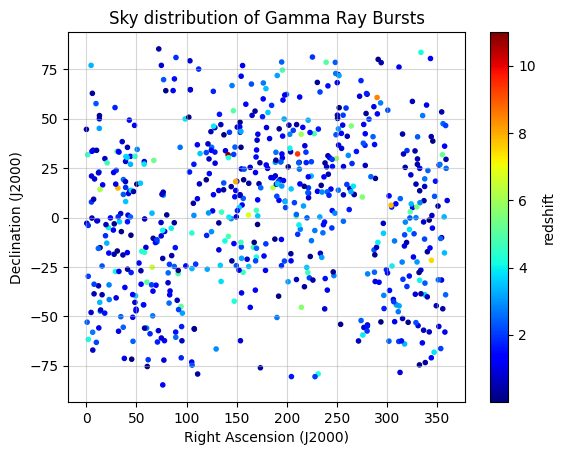

In [6]:
# Location in the sky
plt.scatter(vec_RA, vec_Dec, c=vec_z, cmap='jet', marker=".")
plt.colorbar(label="redshift")
plt.xlabel("Right Ascension (J2000)")
plt.ylabel("Declination (J2000)")
plt.title("Sky distribution of Gamma Ray Bursts")
plt.grid(alpha=0.5)
plt.show()

In [7]:
# this is a plot of the distributions of Gamma Ray Bursts,
# visualizing fluence [erg/cm^2] as a function of the time interval during which 90% of the GRB photon counts are observed (starting at 5% and ending at 95%).

# Can you see two classes there? These are the so-called short GRBs and long GRBs.
# The long ones come from supernovae, the short ones come from neutron star mergers.

vec_fluence = np.array(table['fluence'].astype(float).replace(-999, np.nan))
vec_fluence_err = np.array(table['fluence_error'].astype(float).replace(-999, np.nan))
vec_T90 = np.array(table['T90'].astype(float).replace(-999, np.nan))
vec_T90_err = np.array(table['T90_error'].astype(float).replace(-999, np.nan))

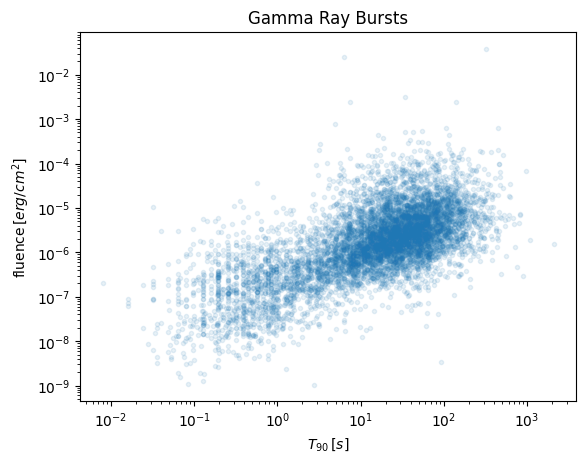

In [8]:
cond = ~np.isnan(vec_T90) & ~np.isnan(vec_fluence) & (vec_T90>0) & (vec_fluence>0)
plt.plot(vec_T90[cond], vec_fluence[cond], '.', alpha=0.1)
plt.xlabel(r"$T_{90}\, [s]$")
plt.ylabel(r"$\text{fluence}\, [erg/cm^2]$")
plt.title("Gamma Ray Bursts")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [9]:
sel_id = np.where(cond)[0]
sub_table = table.loc[sel_id]

In [10]:
sub_table[["T90", "T90_error", "fluence", "fluence_error"]]

,T90,T90_error,fluence,fluence_error
0,48.1290,1.3050,1.7999e-05,5.1172e-08
1,13.5680,1.1450,2.9059e-06,1.8857e-08
2,230.9170,0.9230,1.3665e-05,3.7234e-08
3,48.8970,1.0560,7.0208e-06,4.2396e-08
4,18.1730,0.5710,3.4854e-06,1.7362e-08
...,...,...,...,...
8723,430.0160,1.0940,1.3510e-06,6.3429e-08
8724,90.1760,0.2860,1.3277e-05,6.8674e-08
8725,3.1360,0.5900,2.4858e-08,1.0496e-08
8726,208.5760,1.1180,1.6510e-07,1.7015e-08


Some relevant physical questions you might want to tackle include:

1. Does the distribution contain different sub-populations? How many?
2. What's the threshold between the classes?
3. If you try two clustering methods, do you get more or less the same?
4. How do methods respond to outliers?
5. What variable(s) shows the multi-modality more evidently?
6. Are all GRBs equally likely to be observed?

In [11]:
x = np.log10(vec_T90[cond])
y = np.log10(vec_fluence[cond])
# remember sklearn requires format (n_samples, n_features)
X = np.array([x, y]).T
print(X.shape)
X_1d = np.array([x]).T
print(X_1d.shape)

(7480, 2)
(7480, 1)



**K-means clustering**

In [12]:
# in addition define a KDE
def kde_sklearn(data, bandwidth, kernel, grid):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel = kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

In [13]:
clf_1d = KMeans(n_clusters=2, n_init='auto') # Try 2 clusters (short GRBs and long GRBs)
scaler_1d = StandardScaler()

clf_1d.fit(scaler_1d.fit_transform(X_1d))
centers_1d = scaler_1d.inverse_transform(clf_1d.cluster_centers_) # location of the clusters
labels_1d = clf_1d.predict(scaler_1d.transform(X_1d)) # labels for each of the points

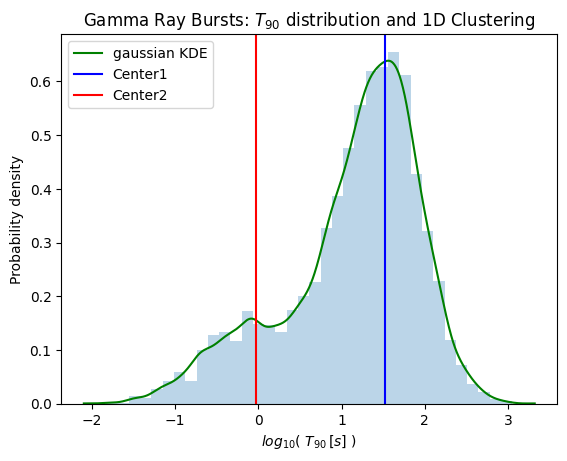

In [14]:
grid = np.linspace(x.min(), x.max(), 1000)
PDF = kde_sklearn(x, 0.1, "gaussian", grid)

plt.hist(X_1d, bins=40, density=True, alpha=0.3)
plt.plot(grid, PDF, "-g", label="gaussian KDE")
plt.axvline(centers_1d[0], color="blue", label="Center1")
plt.axvline(centers_1d[1], color="red", label="Center2")
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel("Probability density")
plt.title("Gamma Ray Bursts: $T_{90}$ distribution and 1D Clustering")
plt.legend()
plt.show()

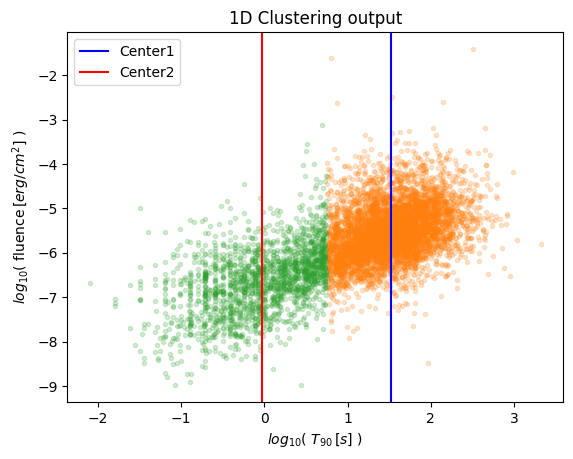

In [15]:
# plot the data color-coded by cluster id
colors = ['C1', 'C2']
for ii in range(2):
    plt.scatter(X[labels_1d==ii, 0], X[labels_1d==ii, 1], color=colors[ii], alpha=0.2, marker='.')
plt.axvline(centers_1d[0], color="blue", label="Center1")
plt.axvline(centers_1d[1], color="red", label="Center2")
plt.title('1D Clustering output');
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.legend()
plt.show()

In [16]:
clf = KMeans(n_clusters=2, n_init='auto') # Try 2 clusters (short GRBs and long GRBs)
scaler = StandardScaler()

clf.fit(scaler.fit_transform(X))
centers = scaler.inverse_transform(clf.cluster_centers_) # location of the clusters
labels = clf.predict(scaler.transform(X)) # labels for each of the points

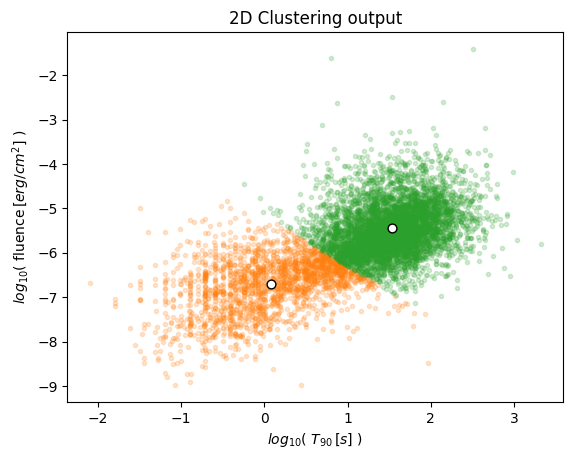

In [17]:
# plot the data color-coded by cluster id
colors = ['C1', 'C2']
for ii in range(2):
    plt.scatter(X[labels==ii, 0], X[labels==ii, 1], color=colors[ii], alpha=0.2, marker='.')
plt.scatter(centers[:, 0], centers[:, 1], s=40, c='w', edgecolors='k')
plt.title('2D Clustering output');
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.show()

**Mean-shift clustering**

Mean-shift clustering can be sensitive to outliers, because it moves points towards nearby dense regions, and outliers (isolated points) can sometimes wrongly start their own small clusters.

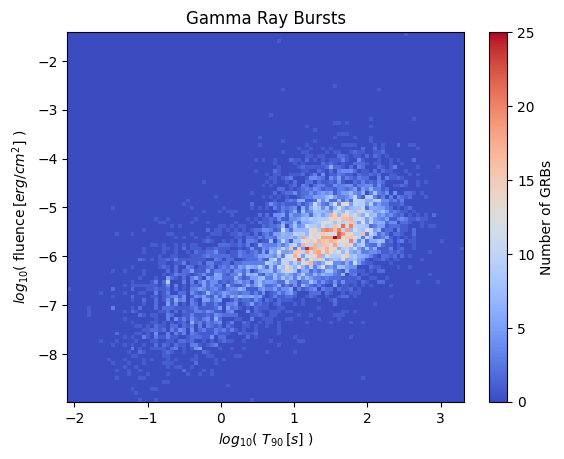

In [18]:
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 100)
plt.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='coolwarm')
plt.colorbar(label="Number of GRBs")
plt.title("Gamma Ray Bursts")
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.show()

In [19]:
# scale data for a better fit
scaler = StandardScaler()
std_X = scaler.fit_transform(X)
# estimate bandwidth and clusters
bandwidth = 0.5
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(std_X)
ms_labels = ms.labels_
ms_centers = scaler.inverse_transform(ms.cluster_centers_)

In [20]:
labels_unique = np.unique(ms_labels)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
0.5
number of estimated clusters : 12


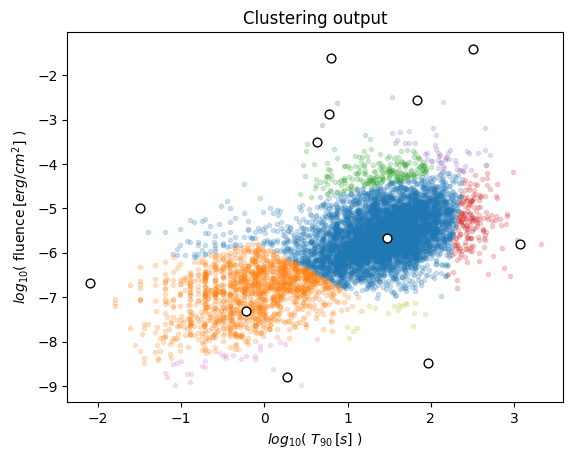

In [21]:
# plot the data color-coded by cluster id
for ii in range(n_clusters):
    plt.scatter(X[ms_labels==ii, 0], X[ms_labels==ii, 1], alpha=0.2, marker='.')
plt.scatter(ms_centers[:, 0], ms_centers[:, 1], s=40, c='w', edgecolors='k')
plt.title('Clustering output');
plt.xlabel(r"$log_{10}$( $T_{90}\, [s]$ )")
plt.ylabel(r"$log_{10}$( $\text{fluence}\, [erg/cm^2]$ )")
plt.show()